<a href="https://colab.research.google.com/github/dellae09/academic-performance-clustering-kmeans-sa/blob/main/02_Prapemrosesan_Posttest_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
**# Tujuan:**
# (1) Profil data awal (RAW) — lengkap (shape, kolom, dtype, missing, unique, contoh)
# (2) Standarisasi kolom + parsing nilai
# (3) Validasi & pelaporan NPM bermasalah (tanpa hapus otomatis)
# (4) Deduplikasi resmi: NPM+Nama+Kelas+Nilai_Raw (sama persis)
# (5) Pemetaan MK -> Soal teoritis -> penyetaraan 0–100
# (6) Simpan clean long + agregasi final: 1 NPM 1 nilai (mean per MK)
# ============================================================


***Cell 1 — Mount Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


***[CELL 02] Import Library + Path Output***

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IN_FILE = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Mentah/Nilai Posttest All (Dari Database).csv"

OUT_DIR = "/content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest"
os.makedirs(OUT_DIR, exist_ok=True)

# output jejak proses
OUT_RAW_PROFILE  = os.path.join(OUT_DIR, "posttest_raw_profile_2025.csv")
OUT_STAGE1_STD   = os.path.join(OUT_DIR, "posttest_stage1_standardized_2025.csv")
OUT_STAGE2_DEDUP = os.path.join(OUT_DIR, "posttest_stage2_deduplicated_2025.csv")
OUT_LONG_CLEAN   = os.path.join(OUT_DIR, "posttest_long_clean_2025.csv")
OUT_AGG_NPM      = os.path.join(OUT_DIR, "posttest_agg_per_npm_2025.csv")

OUT_BAD_NPM   = os.path.join(OUT_DIR, "report_posttest_npm_bermasalah_2025.csv")
OUT_BAD_MK    = os.path.join(OUT_DIR, "report_posttest_mk_tidak_terpetakan_2025.csv")
OUT_BAD_SCALE = os.path.join(OUT_DIR, "report_posttest_penyetaraan_bermasalah_2025.csv")

STRICT_NPM = True   # stop jika ada NPM invalid/fixable
STRICT_MK  = False  # MK unmapped tidak stop, tapi dilaporkan


***[CELL 03] Tabel Soal Teoritis (MK → jumlah soal)***

In [ ]:
SOAL_MAP = {
    "komputer dan pemrograman": 50,
    "pemrograman berorientasi objek": 32,
    "sistem basis data": 28,
    "statistika dan probabilitas": 32,
    "intelligent tutoring system": 36,
    "konsep basis data": 30,
    "desain basis data": 28,
}

MK_ALIASES = {
    "kdp": "komputer dan pemrograman",
    "komdat": "komputer dan pemrograman",
    "pbo": "pemrograman berorientasi objek",
    "oop": "pemrograman berorientasi objek",
    "sbd": "sistem basis data",
    "statprob": "statistika dan probabilitas",
    "statistika": "statistika dan probabilitas",
    "probabilitas": "statistika dan probabilitas",
    "its": "intelligent tutoring system",
    "inteliigent": "intelligent tutoring system",
    "inteliigent tutoring system": "intelligent tutoring system",
    "intelligent tutoring": "intelligent tutoring system",
    "kbd": "konsep basis data",
    "dbd": "desain basis data",
}

***[CELL 04] Utilitas Umum (Read CSV, Normalisasi, Parsing Angka)***

In [ ]:
def read_csv_safely(path: str) -> pd.DataFrame:
    seps = [";", ",", "\t", "|"]
    last_err = None
    for sep in seps:
        try:
            df = pd.read_csv(path, dtype=str, sep=sep, engine="python")
            if df.shape[1] > 1:
                return df
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Gagal membaca CSV. Error terakhir: {last_err}")

def normalize_text(x: str) -> str:
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def to_numeric_safe(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

***[CELL 05] Load RAW Dataset***

In [ ]:
df_raw = read_csv_safely(IN_FILE)
print("RAW loaded (POSTTEST).")

RAW loaded (POSTTEST).


***[CELL 06] Informasi Awal Dataset (RAW)***

INFORMASI AWAL DATASET (RAW) — POSTTEST — SEBELUM PREPROCESSING
Ukuran data (baris, kolom): (447, 4)

Nama kolom (urut asli):
01. NPM
02. nama_lengkap
03. nama_kelas
04. nilai_posttest

Tipe data (dtype) per kolom:


,Kolom,dtype
0,NPM,object
1,nama_lengkap,object
2,nama_kelas,object
3,nilai_posttest,object



Preview 10 baris pertama:


,NPM,nama_lengkap,nama_kelas,nilai_posttest
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,34.00
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,29.00
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,43.00
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,34.00
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,30.00
5,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,39.00
6,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,33.00
7,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,36.00
8,G1F0250023,Ananda Mikola,2025 Komputer dan Pemrograman,36.00
9,G1F025087,Anisa,2025 Komputer dan Pemrograman,31.00



Tabel profil RAW (missing, unik, contoh) — POSTTEST:


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,244,G1F025066
1,nama_lengkap,object,0,0.0,244,Abi Mayu Priamitra
3,nilai_posttest,object,0,0.0,40,34.00
2,nama_kelas,object,0,0.0,7,2025 Komputer dan Pemrograman


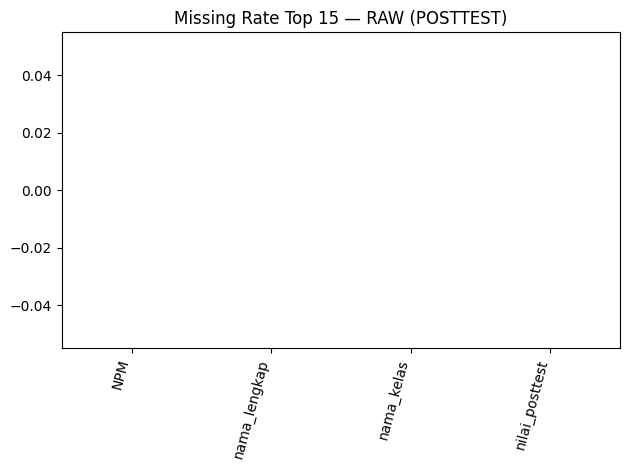

In [ ]:
print("="*110)
print("INFORMASI AWAL DATASET (RAW) — POSTTEST — SEBELUM PREPROCESSING")
print("="*110)

print("Ukuran data (baris, kolom):", df_raw.shape)

print("\nNama kolom (urut asli):")
for i, c in enumerate(df_raw.columns, 1):
    print(f"{i:02d}. {c}")

print("\nTipe data (dtype) per kolom:")
display(df_raw.dtypes.to_frame("dtype").reset_index().rename(columns={"index":"Kolom"}))

print("\nPreview 10 baris pertama:")
display(df_raw.head(10))

# Ringkasan missing & unik (RAW)
raw_profile = pd.DataFrame({
    "Kolom": df_raw.columns,
    "dtype": [str(df_raw[c].dtype) for c in df_raw.columns],
    "Missing_Count": [int(df_raw[c].isna().sum()) for c in df_raw.columns],
    "Missing_Rate": [float(df_raw[c].isna().mean()) for c in df_raw.columns],
    "Unique_Count": [int(df_raw[c].nunique(dropna=True)) for c in df_raw.columns],
    "Contoh_Nilai": [
        df_raw[c].dropna().astype(str).head(1).iloc[0] if df_raw[c].dropna().shape[0] else ""
        for c in df_raw.columns
    ],
}).sort_values(["Missing_Rate","Unique_Count"], ascending=[False, False])

print("\nTabel profil RAW (missing, unik, contoh) — POSTTEST:")
display(raw_profile)

# Grafik missing rate
miss = df_raw.isna().mean().sort_values(ascending=False).head(15)
plt.figure()
miss.plot(kind="bar")
plt.title("Missing Rate Top 15 — RAW (POSTTEST)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

***[CELL 07] (Baru) Simpan Profil RAW***

In [ ]:
print("="*110)
print("SEBELUM SAVE: cek ringkas RAW profile (POSTTEST)")
print("="*110)
print("Rows profile:", raw_profile.shape[0])
display(raw_profile.head(10))

raw_profile.to_csv(OUT_RAW_PROFILE, index=False)
print("Profil RAW (POSTTEST) tersimpan:", OUT_RAW_PROFILE)

SEBELUM SAVE: cek ringkas RAW profile (POSTTEST)
Rows profile: 4


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count,Contoh_Nilai
0,NPM,object,0,0.0,244,G1F025066
1,nama_lengkap,object,0,0.0,244,Abi Mayu Priamitra
3,nilai_posttest,object,0,0.0,40,34.00
2,nama_kelas,object,0,0.0,7,2025 Komputer dan Pemrograman


Profil RAW (POSTTEST) tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_raw_profile_2025.csv


# ***PREPROCESSING***

***[CELL 08] Fungsi Standarisasi Kolom***

In [ ]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = {c: normalize_text(c).lower() for c in df.columns}
    df = df.rename(columns=cols).copy()

    npm_cols   = ["npm", "nim", "id_mahasiswa", "id"]
    nama_cols  = ["nama", "nama_lengkap", "nama mahasiswa", "namalengkap"]
    kelas_cols = ["kelas", "nama_kelas", "class", "kelas_name"]

    # untuk POSTTEST: utamakan nilai_posttest, tapi tetap aman kalau kolomnya generik
    nilai_cols = ["nilai_posttest", "posttest", "nilai", "score", "skor", "nilai_pretest", "pretest"]

    mk_cols    = ["mata_kuliah", "matakuliah", "mk", "nama_mk", "course", "mata kuliah"]

    def pick(existing, candidates):
        for c in candidates:
            if c in existing:
                return c
        return None

    existing = set(df.columns)
    c_npm   = pick(existing, npm_cols)
    c_nama  = pick(existing, nama_cols)
    c_kelas = pick(existing, kelas_cols)
    c_nilai = pick(existing, nilai_cols)
    c_mk    = pick(existing, mk_cols)

    rename_map = {}
    if c_npm:   rename_map[c_npm]   = "NPM"
    if c_nama:  rename_map[c_nama]  = "Nama"
    if c_kelas: rename_map[c_kelas] = "Kelas"
    if c_nilai: rename_map[c_nilai] = "Nilai_Raw"
    if c_mk:    rename_map[c_mk]    = "Mata_Kuliah"

    df = df.rename(columns=rename_map)

    required = ["NPM","Nama","Kelas","Nilai_Raw"]
    missing_req = [c for c in required if c not in df.columns]
    if missing_req:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing_req}. Kolom tersedia: {list(df.columns)}")

    if "Mata_Kuliah" not in df.columns:
        df["Mata_Kuliah"] = ""

    return df

***CELL 09] Standarisasi Kolom + Parsing Nilai (Stage 1)***

In [ ]:
df = standardize_columns(df_raw)

# rapikan whitespace
for c in ["NPM","Nama","Kelas","Mata_Kuliah","Nilai_Raw"]:
    df[c] = df[c].astype(str).str.strip()

# parsing nilai numeric
df["Nilai_Raw_Num"] = to_numeric_safe(df["Nilai_Raw"])

print("="*110)
print("HASIL STAGE 1 — POSTTEST — Setelah Standarisasi + Parsing")
print("="*110)
print("Ukuran:", df.shape)
print("Kolom:", list(df.columns))
display(df.head(10))

# cek missing setelah standarisasi
stage1_profile = pd.DataFrame({
    "Kolom": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "Missing_Count": [int(df[c].isna().sum()) for c in df.columns],
    "Missing_Rate": [float(df[c].isna().mean()) for c in df.columns],
    "Unique_Count": [int(df[c].nunique(dropna=True)) for c in df.columns],
}).sort_values("Missing_Rate", ascending=False)

display(stage1_profile)

HASIL STAGE 1 — POSTTEST — Setelah Standarisasi + Parsing
Ukuran: (447, 6)
Kolom: ['NPM', 'Nama', 'Kelas', 'Nilai_Raw', 'Mata_Kuliah', 'Nilai_Raw_Num']


,NPM,Nama,Kelas,Nilai_Raw,Mata_Kuliah,Nilai_Raw_Num
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,34.00,,34.0
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,29.00,,29.0
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,43.00,,43.0
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,34.00,,34.0
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,30.00,,30.0
5,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,39.00,,39.0
6,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,33.00,,33.0
7,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,36.00,,36.0
8,G1F0250023,Ananda Mikola,2025 Komputer dan Pemrograman,36.00,,36.0
9,G1F025087,Anisa,2025 Komputer dan Pemrograman,31.00,,31.0


,Kolom,dtype,Missing_Count,Missing_Rate,Unique_Count
0,NPM,object,0,0.0,244
1,Nama,object,0,0.0,244
2,Kelas,object,0,0.0,7
3,Nilai_Raw,object,0,0.0,40
4,Mata_Kuliah,object,0,0.0,1
5,Nilai_Raw_Num,float64,0,0.0,40


***[CELL 10] (Baru) Save Stage 1***

In [ ]:
print("="*110)
print("SEBELUM SAVE STAGE 1 — POSTTEST — cek ringkas")
print("="*110)
print("Ukuran:", df.shape)
display(df.head(5))

df.to_csv(OUT_STAGE1_STD, index=False)
print("Stage 1 (POSTTEST) tersimpan:", OUT_STAGE1_STD)

SEBELUM SAVE STAGE 1 — POSTTEST — cek ringkas
Ukuran: (447, 6)


,NPM,Nama,Kelas,Nilai_Raw,Mata_Kuliah,Nilai_Raw_Num
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,34.00,,34.0
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,29.00,,29.0
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,43.00,,43.0
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,34.00,,34.0
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,30.00,,30.0


Stage 1 (POSTTEST) tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_stage1_standardized_2025.csv


***[CELL 11] Validasi NPM (Angkatan 20–25) + Report***

In [ ]:
NPM_VALID_PATTERN = re.compile(r"^G1F0(20|21|22|23|24|25)\d{3}$")

def normalize_npm_raw(x: str) -> str:
    s = str(x).upper().strip()
    s = s.replace(" ", "").replace(".", "")
    s = re.sub(r"[^A-Z0-9]", "", s)
    return s

def suggest_npm_fix(norm: str) -> str:
    if NPM_VALID_PATTERN.match(norm):
        return norm

    s = norm
    if s.startswith("G1F") and not s.startswith("G1F0"):
        s = "G1F0" + s[3:]
    if not s.startswith("G1F0"):
        return ""

    tail = re.sub(r"\D", "", s[4:])
    if len(tail) < 5:
        return ""

    valid_years = {"20","21","22","23","24","25"}
    year = tail[:2] if tail[:2] in valid_years else ""
    if year == "":
        for y in ["20","21","22","23","24","25"]:
            if y in tail:
                year = y
                break
    if year == "":
        return ""

    serial = tail[-3:]
    return f"G1F0{year}{serial}" if len(serial) == 3 else ""

# 1) Hitung status awal
rep_npm = df[["NPM","Nama","Kelas"]].copy()
rep_npm["NPM_Norm"] = rep_npm["NPM"].apply(normalize_npm_raw)
rep_npm["NPM_Saran"] = rep_npm["NPM_Norm"].apply(suggest_npm_fix)

rep_npm["Status"] = np.where(rep_npm["NPM_Norm"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "VALID",
                      np.where(rep_npm["NPM_Saran"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "FIXABLE", "INVALID"))

# 2) Terapkan perbaikan otomatis untuk status FIXABLE
fix_mask = rep_npm["Status"] == "FIXABLE"
if fix_mask.any():
    print(f"Mengaplikasikan perbaikan otomatis pada {int(fix_mask.sum())} baris (POSTTEST)...")
    df["NPM"] = rep_npm["NPM_Saran"].where(fix_mask, df["NPM"])

    # Update status setelah diperbaiki
    rep_npm["NPM_Norm"] = df["NPM"].apply(normalize_npm_raw)
    rep_npm["Status"] = np.where(rep_npm["NPM_Norm"].apply(lambda x: bool(NPM_VALID_PATTERN.match(x))), "VALID", "INVALID")

print("Ringkasan status NPM (setelah auto-fix) — POSTTEST:")
display(rep_npm["Status"].value_counts().to_frame("Jumlah"))

rep_bad = rep_npm[rep_npm["Status"] != "VALID"].drop_duplicates().sort_values(["Status","NPM"])

if rep_bad.shape[0] > 0:
    print("NPM yang tetap INVALID (tidak bisa diperbaiki otomatis) — POSTTEST:")
    display(rep_bad.head(50))
    rep_bad.to_csv(OUT_BAD_NPM, index=False)
    print("Report NPM bermasalah (POSTTEST) tersimpan:", OUT_BAD_NPM)
    if STRICT_NPM:
        raise RuntimeError("Masih ditemukan NPM INVALID yang tidak bisa diperbaiki otomatis. Cek file report.")
else:
    print("Semua NPM kini VALID atau telah diperbaiki (POSTTEST).")

Mengaplikasikan perbaikan otomatis pada 4 baris (POSTTEST)...
Ringkasan status NPM (setelah auto-fix) — POSTTEST:


,Jumlah
Status,
VALID,447


Semua NPM kini VALID atau telah diperbaiki (POSTTEST).


***[CELL 12] Cek Duplikat Resmi (audit) + Deduplikasi (Stage 2)***

In [ ]:
dup_subset = ["NPM","Nama","Kelas","Nilai_Raw"]
dup_n = int(df.duplicated(subset=dup_subset).sum())

print("="*110)
print("AUDIT DUPLIKAT RESMI — POSTTEST")
print("="*110)
print("Definisi duplikat resmi: NPM+Nama+Kelas+Nilai_Raw sama persis")
print("Jumlah duplikat:", dup_n)

if dup_n > 0:
    display(df[df.duplicated(subset=dup_subset, keep=False)].sort_values(dup_subset).head(50))

before = df.shape[0]
df_dedup = df.drop_duplicates(subset=dup_subset, keep="first").copy()
after = df_dedup.shape[0]

print("\nHASIL DEDUPLIKASI — POSTTEST")
print("Sebelum:", before, "| Sesudah:", after, "| Terhapus:", before-after)

print("\nBentuk data Stage 2 (dedup) — POSTTEST:")
print("Ukuran:", df_dedup.shape)
display(df_dedup.head(10))

AUDIT DUPLIKAT RESMI — POSTTEST
Definisi duplikat resmi: NPM+Nama+Kelas+Nilai_Raw sama persis
Jumlah duplikat: 0

HASIL DEDUPLIKASI — POSTTEST
Sebelum: 447 | Sesudah: 447 | Terhapus: 0

Bentuk data Stage 2 (dedup) — POSTTEST:
Ukuran: (447, 6)


,NPM,Nama,Kelas,Nilai_Raw,Mata_Kuliah,Nilai_Raw_Num
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,34.00,,34.0
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,29.00,,29.0
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,43.00,,43.0
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,34.00,,34.0
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,30.00,,30.0
5,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,39.00,,39.0
6,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,33.00,,33.0
7,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,36.00,,36.0
8,G1F025023,Ananda Mikola,2025 Komputer dan Pemrograman,36.00,,36.0
9,G1F025087,Anisa,2025 Komputer dan Pemrograman,31.00,,31.0


***[CELL 13] Save Stage 2***

In [ ]:
print("="*110)
print("SEBELUM SAVE STAGE 2 — POSTTEST — cek ringkas")
print("="*110)
print("Ukuran:", df_dedup.shape)
display(df_dedup.head(5))

df_dedup.to_csv(OUT_STAGE2_DEDUP, index=False)
print("Stage 2 (POSTTEST) tersimpan:", OUT_STAGE2_DEDUP)

SEBELUM SAVE STAGE 2 — POSTTEST — cek ringkas
Ukuran: (447, 6)


,NPM,Nama,Kelas,Nilai_Raw,Mata_Kuliah,Nilai_Raw_Num
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,34.00,,34.0
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,29.00,,29.0
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,43.00,,43.0
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,34.00,,34.0
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,30.00,,30.0


Stage 2 (POSTTEST) tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_stage2_deduplicated_2025.csv


***[CELL 14] Pemetaan MK + Report MK tidak terpetakan***

In [ ]:
def infer_mk(row) -> str:
    mk = normalize_text(row.get("Mata_Kuliah", "")).lower()
    kelas = normalize_text(row.get("Kelas", "")).lower()
    blob = f"{mk} {kelas}"

    for k_alias, mk_std in MK_ALIASES.items():
        if k_alias in blob:
            return mk_std
    for mk_std in SOAL_MAP.keys():
        if mk_std in blob:
            return mk_std
    return ""

df_dedup["MK_Std"] = df_dedup.apply(infer_mk, axis=1)
df_dedup["Soal_Teoritis"] = df_dedup["MK_Std"].map(SOAL_MAP)

unmapped = df_dedup[df_dedup["MK_Std"].eq("")].copy()

print("="*110)
print("AUDIT PEMETAAN MK — POSTTEST")
print("="*110)
print("Total baris:", df_dedup.shape[0])
print("MK terpetakan:", int((df_dedup["MK_Std"] != "").sum()))
print("MK tidak terpetakan:", unmapped.shape[0])

if unmapped.shape[0] > 0:
    rep_mk = unmapped[["NPM","Nama","Kelas","Mata_Kuliah","Nilai_Raw"]].drop_duplicates()
    display(rep_mk.head(30))
    rep_mk.to_csv(OUT_BAD_MK, index=False)
    print("Report MK tidak terpetakan (POSTTEST) tersimpan:", OUT_BAD_MK)

    if STRICT_MK:
        raise RuntimeError("Ada MK tidak terpetakan. Perbaiki SOAL_MAP/MK_ALIASES lalu ulang.")

AUDIT PEMETAAN MK — POSTTEST
Total baris: 447
MK terpetakan: 447
MK tidak terpetakan: 0


***[CELL 15] Penyetaraan 0–100 (Pretest) + Audit skala bermasalah***

AUDIT PENYETARAAN 0–100 — POSTTEST
Baris bermasalah (NaN/<0/>100): 0


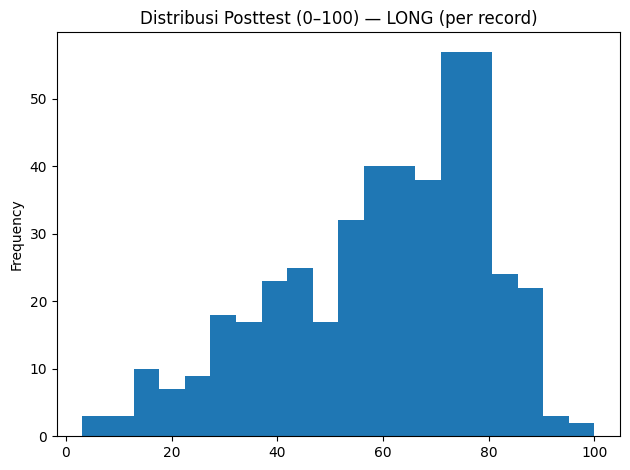

In [ ]:
df_dedup["Posttest_0_100"] = np.nan
df_dedup["Posttest_Method"] = ""

mask_have_soal = df_dedup["Soal_Teoritis"].notna() & df_dedup["Nilai_Raw_Num"].notna()

mask_count = mask_have_soal & (df_dedup["Nilai_Raw_Num"] <= df_dedup["Soal_Teoritis"])
df_dedup.loc[mask_count, "Posttest_0_100"] = (df_dedup.loc[mask_count, "Nilai_Raw_Num"] / df_dedup.loc[mask_count, "Soal_Teoritis"]) * 100
df_dedup.loc[mask_count, "Posttest_Method"] = "raw_as_correct_count"

mask_pct = mask_have_soal & (df_dedup["Nilai_Raw_Num"] > df_dedup["Soal_Teoritis"])
df_dedup.loc[mask_pct, "Posttest_0_100"] = df_dedup.loc[mask_pct, "Nilai_Raw_Num"].clip(0, 100)
df_dedup.loc[mask_pct, "Posttest_Method"] = "raw_as_percent_clipped"

bad_scale = df_dedup[
    df_dedup["Posttest_0_100"].isna() |
    (df_dedup["Posttest_0_100"] < 0) |
    (df_dedup["Posttest_0_100"] > 100)
].copy()

print("="*110)
print("AUDIT PENYETARAAN 0–100 — POSTTEST")
print("="*110)
print("Baris bermasalah (NaN/<0/>100):", bad_scale.shape[0])

if bad_scale.shape[0] > 0:
    display(bad_scale[["NPM","Nama","Kelas","MK_Std","Soal_Teoritis","Nilai_Raw","Nilai_Raw_Num","Posttest_0_100","Posttest_Method"]].head(50))
    bad_scale.to_csv(OUT_BAD_SCALE, index=False)
    print("Report skala bermasalah (POSTTEST) tersimpan:", OUT_BAD_SCALE)

plt.figure()
df_dedup["Posttest_0_100"].dropna().plot(kind="hist", bins=20)
plt.title("Distribusi Posttest (0–100) — LONG (per record)")
plt.tight_layout()
plt.show()

***[CELL 16] Bentuk LONG Clean + tampilkan dulu baru save***

In [ ]:
long_cols = ["NPM","Nama","Kelas","Mata_Kuliah","MK_Std","Soal_Teoritis","Nilai_Raw_Num","Posttest_0_100","Posttest_Method"]
df_long = df_dedup[long_cols].copy()

print("="*110)
print("BENTUK DATA LONG (Bersih) — POSTTEST — sebelum SAVE")
print("="*110)
print("Ukuran:", df_long.shape)
print("NPM unik:", df_long["NPM"].nunique())
print("MK_Std unik:", df_long["MK_Std"].nunique())
display(df_long.head(10))

df_long.to_csv(OUT_LONG_CLEAN, index=False)
print("LONG clean (POSTTEST) tersimpan:", OUT_LONG_CLEAN)

BENTUK DATA LONG (Bersih) — POSTTEST — sebelum SAVE
Ukuran: (447, 9)
NPM unik: 244
MK_Std unik: 7


,NPM,Nama,Kelas,Mata_Kuliah,MK_Std,Soal_Teoritis,Nilai_Raw_Num,Posttest_0_100,Posttest_Method
0,G1F025066,Abi Mayu Priamitra,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,34.0,68.0,raw_as_correct_count
1,G1F025051,Abiemayu Herlaputra,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,29.0,58.0,raw_as_correct_count
2,G1F025071,Adam Fakhry Sanjaya,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,43.0,86.0,raw_as_correct_count
3,G1F025017,Ahmad Nadhif Arsyalan,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,34.0,68.0,raw_as_correct_count
4,G1F025046,Ahmad Rafi Pratiza,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,30.0,60.0,raw_as_correct_count
5,G1F025019,Aida Silva Mahyudin,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,39.0,78.0,raw_as_correct_count
6,G1F025012,Aisyah Dewi,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,33.0,66.0,raw_as_correct_count
7,G1F025005,Amanda Pratiwi,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,36.0,72.0,raw_as_correct_count
8,G1F025023,Ananda Mikola,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,36.0,72.0,raw_as_correct_count
9,G1F025087,Anisa,2025 Komputer dan Pemrograman,,komputer dan pemrograman,50,31.0,62.0,raw_as_correct_count


LONG clean (POSTTEST) tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_long_clean_2025.csv


***[CELL 17] FINAL AGREGASI: 1 NPM = 1 NILAI (mean) + tampilkan dulu baru save***

BENTUK DATA FINAL (WIDE) — POSTTEST — sebelum SAVE
Ukuran: (244, 11)
Duplikasi NPM: 0


,NPM,Nama,MK_KDP,MK_PBO,MK_SBD,MK_STATPROB,MK_ITS,MK_KBD,MK_DBD,Jumlah_MK_Diambil,Nilai_Posttest_Final_0_100
0,G1F021045,Ananda Naila Evril,NaN,NaN,NaN,40.62,NaN,NaN,NaN,1,40.62
1,G1F022002,Ulfa,NaN,NaN,NaN,NaN,33.33,NaN,NaN,1,33.33
2,G1F022005,Ahmad Fadhila,NaN,NaN,NaN,NaN,NaN,NaN,64.29,1,64.29
3,G1F022007,AHMAD DWICAHYADI,NaN,NaN,NaN,NaN,41.67,NaN,NaN,1,41.67
4,G1F022008,Meisy Dianita,NaN,NaN,NaN,NaN,88.89,NaN,NaN,1,88.89
5,G1F022013,ANNAS ZAM ZAM,NaN,NaN,NaN,NaN,36.11,NaN,NaN,1,36.11
6,G1F022014,Tanya Dwi Agustin,NaN,NaN,NaN,NaN,72.22,NaN,NaN,1,72.22
7,G1F022016,Epriantravolta Saragih,NaN,87.5,NaN,NaN,NaN,NaN,NaN,1,87.50
8,G1F022019,Della Erlina,NaN,NaN,NaN,NaN,80.56,NaN,NaN,1,80.56
9,G1F022020,Ahmad Ilham Febryadi,NaN,NaN,NaN,NaN,72.22,NaN,NaN,1,72.22


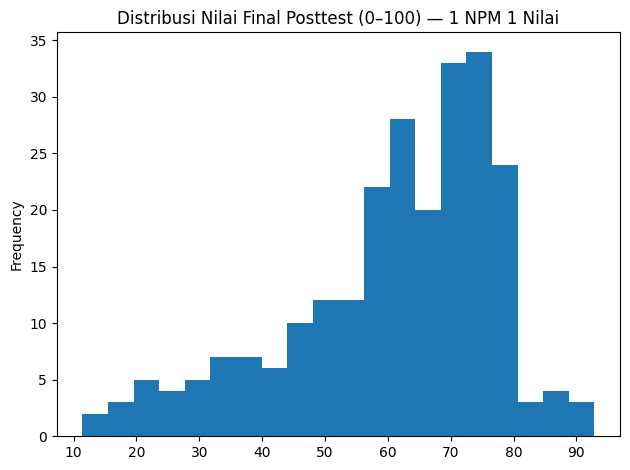

Final WIDE (POSTTEST) tersimpan: /content/drive/MyDrive/SKRIPSI S1 - SISTEM INFORMASI/Pengolahan Data/Data Bersih/Dataset Clean/Posttest/posttest_final_wide_1npm_1nilai_2025.csv


In [ ]:
# ============================================================
# 10) Susun urutan kolom (TANPA Posttest_Asli)
# Output kolom:
# NPM | Nama | MK_* | Jumlah_MK_Diambil | Nilai_Posttest_Final_0_100
# ============================================================

# ganti nama final agar sesuai permintaan
pivot_mk["Nilai_Posttest_Final_0_100"] = pivot_mk["Posttest_Final_0_100"]

final_wide = (
    pivot_mk.merge(name_mode, on="NPM", how="left")
)

final_wide = final_wide[
    ["NPM","Nama"] + mk_cols_final + ["Jumlah_MK_Diambil","Nilai_Posttest_Final_0_100"]
].copy()

# ============================================================
# Pembulatan 2 angka di belakang koma (SEMUA skala 0–100)
# ============================================================
round_cols = mk_cols_final + ["Nilai_Posttest_Final_0_100"]
final_wide[round_cols] = final_wide[round_cols].round(2)

print("="*110)
print("BENTUK DATA FINAL (WIDE) — POSTTEST — sebelum SAVE")
print("="*110)
print("Ukuran:", final_wide.shape)
print("Duplikasi NPM:", int(final_wide["NPM"].duplicated().sum()))
display(final_wide.head(10))

plt.figure()
final_wide["Nilai_Posttest_Final_0_100"].dropna().plot(kind="hist", bins=20)
plt.title("Distribusi Nilai Final Posttest (0–100) — 1 NPM 1 Nilai")
plt.tight_layout()
plt.show()

# Save
OUT_FINAL_WIDE = os.path.join(OUT_DIR, "posttest_final_wide_1npm_1nilai_2025.csv")
final_wide.to_csv(OUT_FINAL_WIDE, index=False)
print("Final WIDE (POSTTEST) tersimpan:", OUT_FINAL_WIDE)
